# Quantum Cost Pipeline and Topology Mapping

**Motivating question:** If an abstract quantum algorithm looks fast on a slide, what full-stack costs still have to be paid before that speedup becomes useful?

**Learning goals**
- distinguish an abstract quantum circuit from a full execution workflow
- understand state preparation as an input-loading and preprocessing cost
- see why logical two-qubit interactions must be mapped onto physical device constraints
- compare how topology changes routing overhead
- understand why repeated measurements and classical post-processing belong in the real cost model
- treat this notebook's routing and compilation ideas as pedagogical abstractions, not as full quantum compilers

*This notebook accompanies Lecture 03 on computational complexity. It is designed for live demo and self-study.*


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'utilities' / 'complexity_utils.py').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import math
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown

from utilities.complexity_utils import (
    display_wrapped,
    instructor_prompt,
    markdown_box,
    plot_abstraction_gap,
    plot_component_tradeoff,
    plot_grouped_bars,
    plot_logical_vs_physical,
    plot_quantum_pipeline,
    plot_stacked_cost_bars,
    plot_topology_gallery,
    setup_lecture_style,
    timed_call,
)

setup_lecture_style()
rng = np.random.default_rng(7)
pd.options.display.float_format = lambda value: f'{value:,.3g}'


This notebook follows the shared Lecture 03 visual rhythm: a motivating question, a small model, one dominant visual, a compact comparison, and a short takeaway.

This notebook bridges from classical complexity intuition into realistic quantum execution. The earlier notebooks built abstract scaling language; now the question is how full-stack workflow costs reshape that story on constrained hardware.

## 1. Why isn't a quantum algorithm just a circuit diagram?

**Concept question:** What gets hidden when we talk only about an ideal circuit and ignore the execution stack around it?


In theory discussions, a quantum algorithm is often presented as a clean sequence of logical gates. That view is useful, but incomplete. A real execution pipeline also has to load data, adapt the logical circuit to device constraints, run repeated measurements, and process classical outputs.

This section is a framing section. The goal is not to introduce a hardware simulator. The goal is to make students suspicious of any complexity claim that silently ignores all layers outside the ideal logical circuit.


In [2]:
abstract_view = ['problem description', 'logical circuit', 'asymptotic claim']
pipeline_view = [
    'classical problem',
    'encoding',
    'logical circuit',
    'optimization',
    'transpilation',
    'topology mapping',
    'execution',
    'measurements',
    'post-processing',
]

framing_df = pd.DataFrame(
    {
        'View': ['Abstract slide view', 'Execution pipeline view'],
        'Named stages': [len(abstract_view), len(pipeline_view)],
        'Typical emphasis': ['algorithmic idea', 'full-stack cost model'],
    }
)


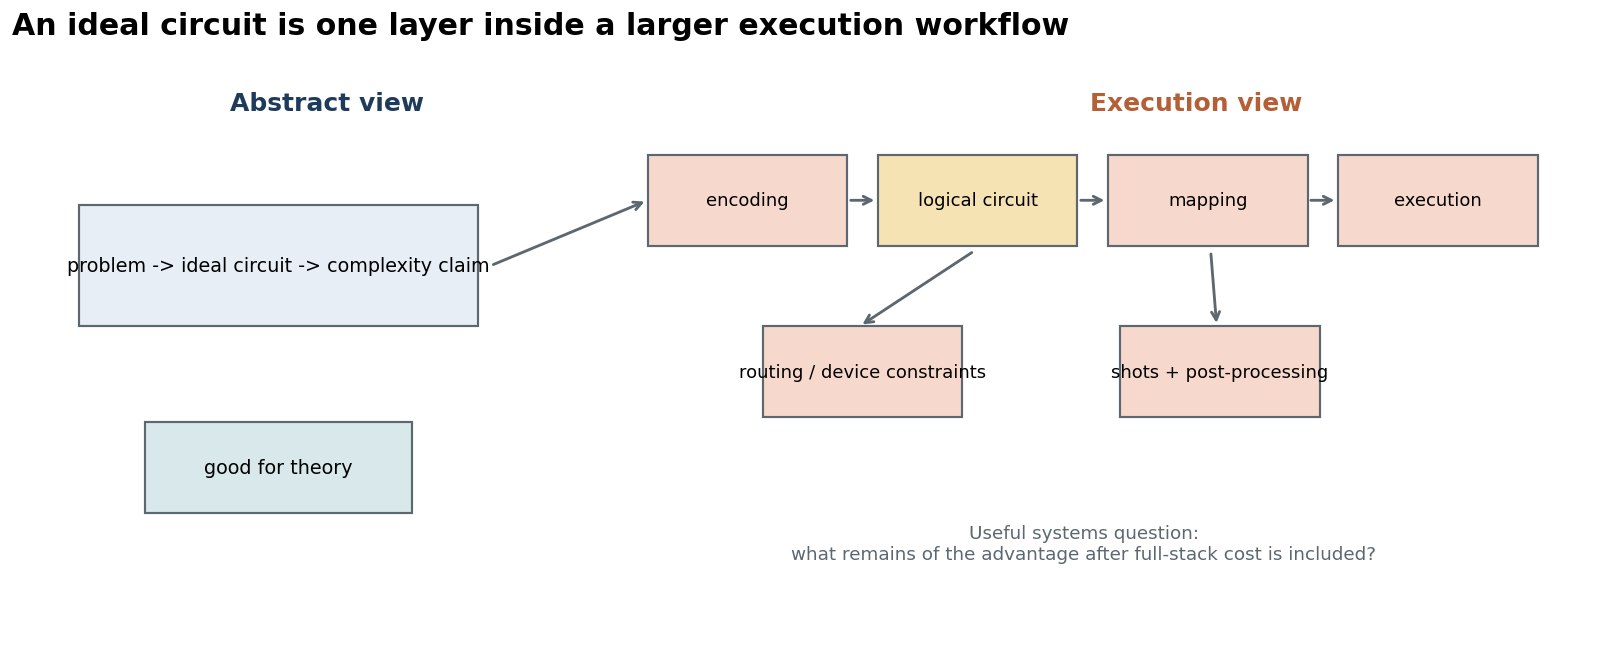

In [3]:
plot_abstraction_gap(
    title='An ideal circuit is one layer inside a larger execution workflow',
)
plt.show()


The abstract view is still valuable, but it suppresses where costs can re-enter. Once we move to execution, costs appear before the circuit, inside the compilation process, and after the quantum device returns samples.


In [4]:
comparison_df = pd.DataFrame(
    {
        'Question': [
            'What object is centered?',
            'What costs are visible?',
            'What can be hidden accidentally?',
        ],
        'Abstract view': [
            'logical circuit or query model',
            'ideal gate/query counts',
            'data movement, routing, shots, classical processing',
        ],
        'Execution view': [
            'workflow from input to usable answer',
            'loading, mapping, routing, shots, post-processing',
            'fewer hidden layers, but still only a toy full-stack model here',
        ],
    }
)
display_wrapped(comparison_df)


,Question,Abstract view,Execution view
0,What object is centered?,logical circuit or query model,workflow from input to usable answer
1,What costs are visible?,ideal gate/query counts,"loading, mapping, routing, shots, post-processing"
2,What can be hidden accidentally?,"data movement, routing, shots, classical processing","fewer hidden layers, but still only a toy full-stack model here"


In [5]:
display_wrapped(framing_df)


,View,Named stages,Typical emphasis
0,Abstract slide view,3,algorithmic idea
1,Execution pipeline view,9,full-stack cost model


In [6]:
display_wrapped(Markdown(markdown_box(
    'A quantum algorithm on a slide is not the whole computational object. Complexity can reappear in the layers required to make that circuit executable.'
)))


> **Takeaway:**
> A quantum algorithm on a slide is not the whole computational object. Complexity can reappear in the layers required to make that circuit executable.

In [7]:
display_wrapped(Markdown(instructor_prompt(
    'If someone shows only the logical circuit and the asymptotic gain, which missing stages would you ask about before trusting the practical significance?'
)))


> **Instructor Prompt:**
> If someone shows only the logical circuit and the asymptotic gain, which missing stages would you ask about before trusting the practical significance?

## 2. From classical problem to quantum workflow

**Concept question:** What stages sit between a classical problem statement and a usable classical answer returned from a quantum device?


This section introduces the notebook's anchor picture: the execution pipeline. It is intentionally simple, but each stage corresponds to a real kind of work. The main teaching goal is to show that the circuit is neither the beginning nor the end of the story.


In [8]:
workflow_stages = [
    'classical problem',
    'encoding / state preparation',
    'logical circuit',
    'optimization',
    'transpilation',
    'mapping to topology',
    'execution',
    'repeated measurements',
    'classical post-processing',
]

stage_description_df = pd.DataFrame(
    {
        'Stage': workflow_stages,
        'What is being modeled': [
            'problem definition and classical data',
            'moving information into a quantum-friendly form',
            'ideal algorithmic interaction pattern',
            'simplifying the circuit before device constraints',
            'rewriting gates into a device-friendly set',
            'placing qubits and interactions on hardware connectivity',
            'running the compiled program on the device',
            'sampling outputs many times',
            'turning counts into a usable answer',
        ],
    }
)


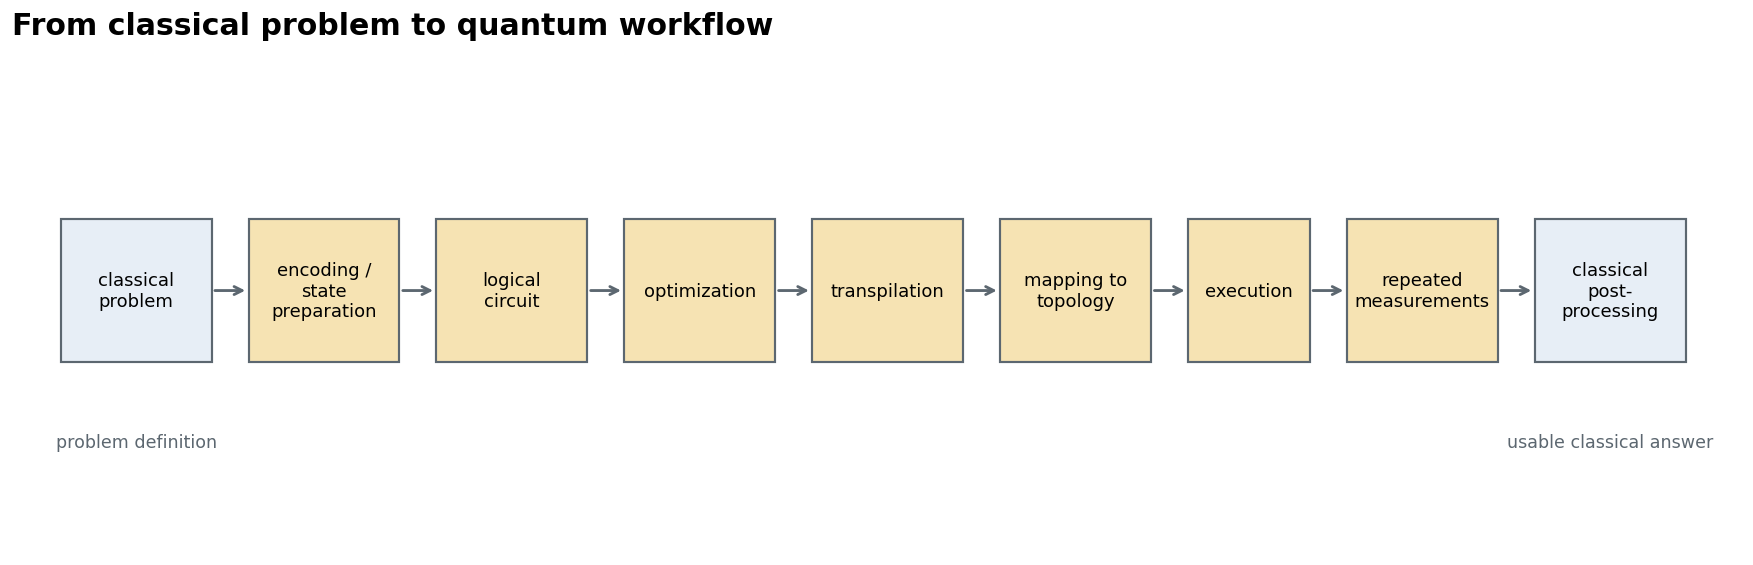

In [9]:
plot_quantum_pipeline(
    workflow_stages,
    title='From classical problem to quantum workflow',
)
plt.show()


Read the pipeline from left to right. The earlier stages resemble classical preprocessing and data movement; the middle stages reflect compilation and hardware adaptation; the final stages remind us that the raw quantum output is usually a collection of samples, not the final answer itself.


In [10]:
display_wrapped(stage_description_df)


,Stage,What is being modeled
0,classical problem,problem definition and classical data
1,encoding / state preparation,moving information into a quantum-friendly form
2,logical circuit,ideal algorithmic interaction pattern
3,optimization,simplifying the circuit before device constraints
4,transpilation,rewriting gates into a device-friendly set
5,mapping to topology,placing qubits and interactions on hardware connectivity
6,execution,running the compiled program on the device
7,repeated measurements,sampling outputs many times
8,classical post-processing,turning counts into a usable answer


In [11]:
pipeline_cost_estimate_df = pd.DataFrame(
    {
        'Stage': workflow_stages,
        'Toy relative effort units': [2, 6, 5, 2, 3, 6, 4, 8, 3],
        'Why effort can appear': [
            'problem size and data collection',
            'input-loading / encoding work',
            'algorithmic core',
            'circuit rewrites',
            'basis adaptation',
            'hardware constraints',
            'device runtime',
            'shots for stable statistics',
            'classical reduction of counts',
        ],
    }
)
display_wrapped(pipeline_cost_estimate_df)


,Stage,Toy relative effort units,Why effort can appear
0,classical problem,2,problem size and data collection
1,encoding / state preparation,6,input-loading / encoding work
2,logical circuit,5,algorithmic core
3,optimization,2,circuit rewrites
4,transpilation,3,basis adaptation
5,mapping to topology,6,hardware constraints
6,execution,4,device runtime
7,repeated measurements,8,shots for stable statistics
8,classical post-processing,3,classical reduction of counts


In [12]:
display_wrapped(Markdown(markdown_box(
    'The circuit is a middle stage, not the whole computation. A realistic cost model tracks the full path from classical input to classical output.'
)))


> **Takeaway:**
> The circuit is a middle stage, not the whole computation. A realistic cost model tracks the full path from classical input to classical output.

In [13]:
display_wrapped(Markdown(instructor_prompt(
    'Which pipeline stage feels most likely to be forgotten when people talk casually about quantum speedup?'
)))


> **Instructor Prompt:**
> Which pipeline stage feels most likely to be forgotten when people talk casually about quantum speedup?

## 3. State preparation as input-loading cost

**Concept question:** Why can loading or encoding the input already dominate the cost before the algorithmic core even starts?


In classical systems, preprocessing and data movement already matter. Quantum workflows have the same issue. If we need to convert a large classical object into a quantum-friendly representation, that conversion is part of the total cost.

The toy model below is intentionally simple. It compares an idealized algorithmic core with a state-preparation cost that grows linearly with the amount of classical data being loaded.


In [14]:
def toy_state_preparation_cost(n):
    """Dense loading toy model: work grows with the amount of classical data moved."""
    return n


def toy_logical_core_cost(n):
    """Toy algorithmic core: chosen only to contrast with loading cost, not to model one real algorithm."""
    return np.sqrt(n)


state_sizes = np.array([8, 16, 32, 64, 128, 256, 512, 1024])
state_prep_costs = np.array([toy_state_preparation_cost(int(n)) for n in state_sizes], dtype=float)
logical_core_costs = np.array([toy_logical_core_cost(int(n)) for n in state_sizes], dtype=float)
total_state_pipeline_costs = state_prep_costs + logical_core_costs


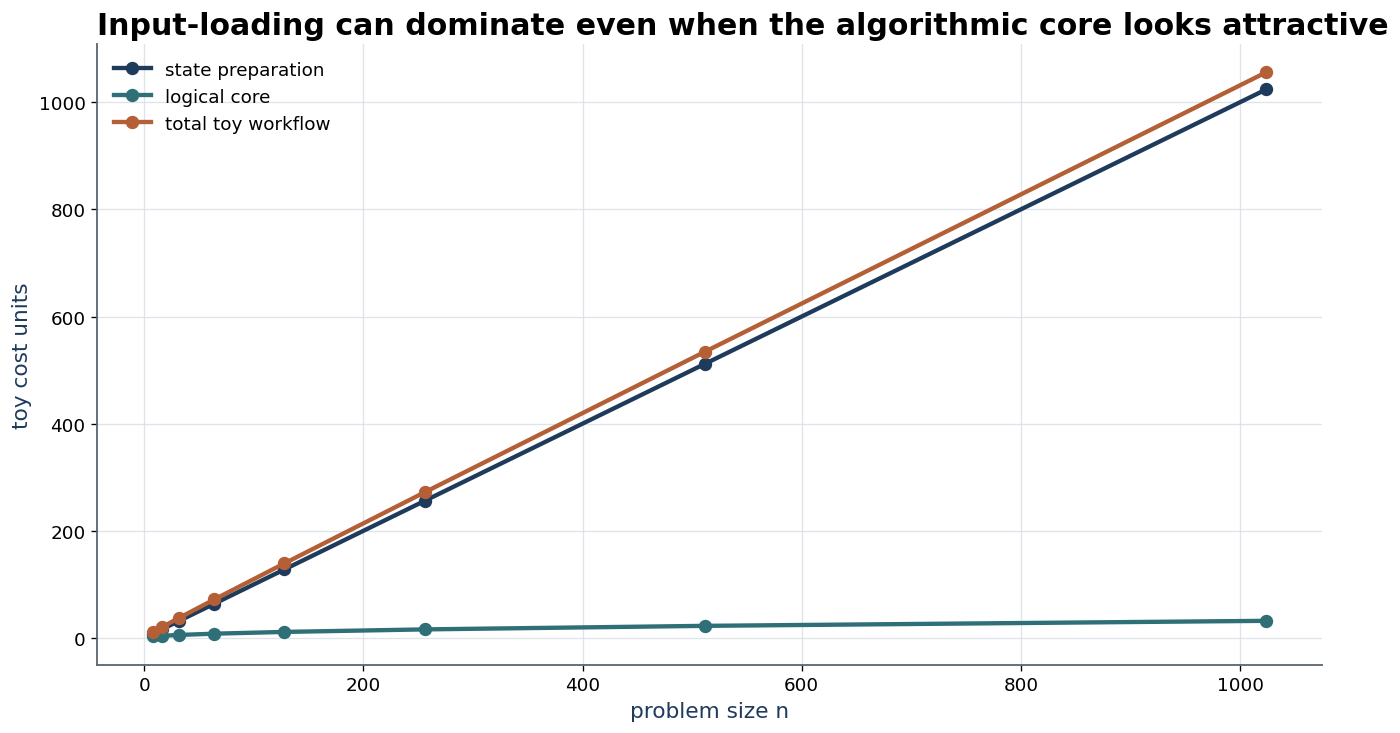

In [15]:
plot_component_tradeoff(
    state_sizes,
    {
        'state preparation': state_prep_costs,
        'logical core': logical_core_costs,
        'total toy workflow': total_state_pipeline_costs,
    },
    title='Input-loading can dominate even when the algorithmic core looks attractive',
    xlabel='problem size n',
    ylabel='toy cost units',
)
plt.show()


The visual should be read as a warning, not as a theorem. A quantum core may scale attractively, but if the input-loading cost is already large, the total end-to-end workflow can still look expensive.


In [16]:
state_prep_formula_df = pd.DataFrame(
    {
        'Component': ['state preparation', 'logical core', 'total toy workflow'],
        'Toy expression': ['n', 'sqrt(n)', 'n + sqrt(n)'],
        'Interpretation': [
            'loading or encoding classical data',
            'idealized algorithmic advantage claim',
            'what a user might actually have to pay',
        ],
    }
)
display_wrapped(state_prep_formula_df)


,Component,Toy expression,Interpretation
0,state preparation,n,loading or encoding classical data
1,logical core,sqrt(n),idealized algorithmic advantage claim
2,total toy workflow,n + sqrt(n),what a user might actually have to pay


In [17]:
def normalize_dense_vector(size, rng=None):
    """Toy dense-state preparation proxy: allocate and normalize a classical vector."""
    if rng is None:
        rng = np.random.default_rng(0)
    data = rng.normal(size=size)
    return data / np.linalg.norm(data)


state_prep_timing_rows = []
for size in [2**8, 2**10, 2**12, 2**14]:
    _, stats = timed_call(normalize_dense_vector, size, rng=rng, repeat=3, warmup=1)
    state_prep_timing_rows.append(
        {
            'vector length': size,
            'measured normalization time (ms)': 1000 * stats['mean_s'],
            'toy core cost sqrt(n)': math.sqrt(size),
        }
    )

state_prep_timing_df = pd.DataFrame(state_prep_timing_rows)
display_wrapped(state_prep_timing_df)


,vector length,measured normalization time (ms),toy core cost sqrt(n)
0,256,0.00703,16
1,1024,0.0355,32
2,4096,0.0499,64
3,16384,0.124,128


In [18]:
display_wrapped(Markdown(markdown_box(
    'State preparation is analogous to input-loading and preprocessing in classical systems. If it is expensive, it belongs in the complexity story.'
)))


> **Takeaway:**
> State preparation is analogous to input-loading and preprocessing in classical systems. If it is expensive, it belongs in the complexity story.

In [19]:
display_wrapped(Markdown(instructor_prompt(
    'If the algorithmic core looks sublinear or square-root-like, what would happen to the overall gain if state preparation still scales linearly with the full input?'
)))


> **Instructor Prompt:**
> If the algorithmic core looks sublinear or square-root-like, what would happen to the overall gain if state preparation still scales linearly with the full input?

## 4. Logical circuit vs physical device

**Concept question:** Why can a perfectly reasonable logical interaction pattern become awkward once it has to live on a constrained device?


Logical circuits are usually described as if any required interaction can happen wherever it is needed. Real devices do not work that way. A device topology tells us which qubits can interact directly, and anything outside those local neighborhoods must be adapted.

The model below is deliberately small and pedagogical: six logical qubits with a few required two-qubit interactions. The point is to make the gap between logical intent and physical feasibility visible.


In [20]:
def device_edges(kind, num_qubits):
    """Return undirected edges for a small pedagogical device topology."""
    if kind == 'all_to_all':
        return [(i, j) for i in range(num_qubits) for j in range(i + 1, num_qubits)]
    if kind == 'line':
        return [(i, i + 1) for i in range(num_qubits - 1)]
    if kind == 'ring':
        edges = [(i, i + 1) for i in range(num_qubits - 1)]
        if num_qubits > 2:
            edges.append((num_qubits - 1, 0))
        return edges
    if kind == 'grid':
        cols = int(np.ceil(np.sqrt(num_qubits)))
        edges = []
        for i in range(num_qubits):
            r, c = divmod(i, cols)
            if c + 1 < cols and i + 1 < num_qubits:
                edges.append((i, i + 1))
            down = i + cols
            if down < num_qubits:
                edges.append((i, down))
        return edges
    raise ValueError(f'Unknown topology: {kind}')


def device_adjacency(kind, num_qubits):
    adjacency = {node: set() for node in range(num_qubits)}
    for u, v in device_edges(kind, num_qubits):
        adjacency[u].add(v)
        adjacency[v].add(u)
    return adjacency


def shortest_device_distance(kind, num_qubits, start, target):
    if start == target:
        return 0
    adjacency = device_adjacency(kind, num_qubits)
    queue = deque([(start, 0)])
    visited = {start}
    while queue:
        node, distance = queue.popleft()
        for neighbor in adjacency[node]:
            if neighbor == target:
                return distance + 1
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, distance + 1))
    raise ValueError('Topology should be connected in these toy examples.')


def routing_detail_df(logical_edges, kind, num_qubits):
    rows = []
    for q0, q1 in logical_edges:
        distance = shortest_device_distance(kind, num_qubits, q0, q1)
        rows.append(
            {
                'logical interaction': f'({q0}, {q1})',
                'shortest device distance': distance,
                'extra routing steps (toy)': max(0, distance - 1),
                'directly supported?': distance == 1,
            }
        )
    return pd.DataFrame(rows)


logical_qubit_count = 6
logical_interactions = [(0, 5), (0, 2), (1, 4), (2, 3), (3, 5)]
line_routing_df = routing_detail_df(logical_interactions, 'line', logical_qubit_count)


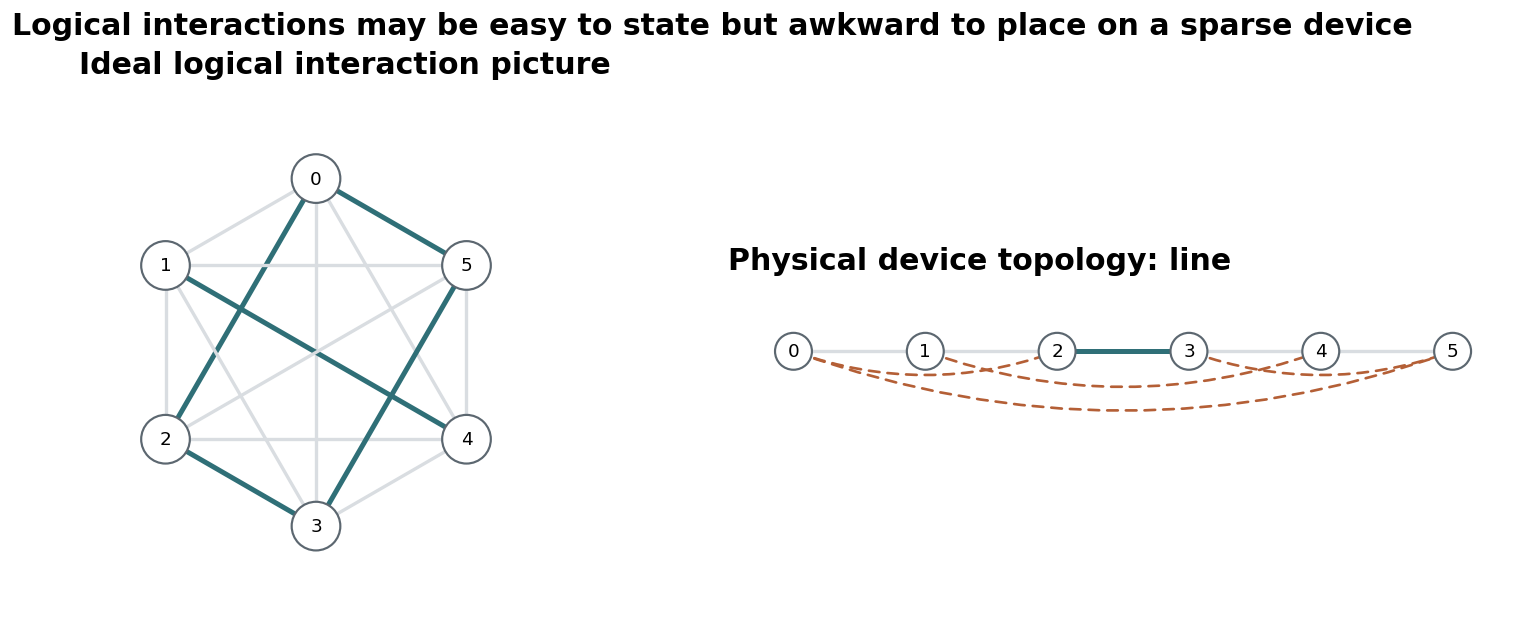

In [21]:
plot_logical_vs_physical(
    logical_interactions,
    num_qubits=logical_qubit_count,
    physical_kind='line',
    title='Logical interactions may be easy to state but awkward to place on a sparse device',
)
plt.show()


On the left, the logical picture only records which pairs need to interact. On the right, the device only offers nearest-neighbor links in a line. Dashed links indicate interactions the algorithm wants but the hardware does not provide directly.


In [22]:
logical_vs_physical_df = pd.DataFrame(
    {
        'Property': [
            'logical qubits',
            'required two-qubit interactions',
            'line-device direct support',
            'line-device nonlocal interactions',
        ],
        'Value': [
            logical_qubit_count,
            len(logical_interactions),
            int(line_routing_df['directly supported?'].sum()),
            int((~line_routing_df['directly supported?']).sum()),
        ],
    }
)
display_wrapped(logical_vs_physical_df)


,Property,Value
0,logical qubits,6
1,required two-qubit interactions,5
2,line-device direct support,1
3,line-device nonlocal interactions,4


In [23]:
direct_support_df = pd.DataFrame(
    {
        'topology': ['all-to-all', 'line', 'ring', 'grid'],
        'directly supported interactions': [
            int(routing_detail_df(logical_interactions, kind, logical_qubit_count)['directly supported?'].sum())
            for kind in ['all_to_all', 'line', 'ring', 'grid']
        ],
    }
)
display_wrapped(direct_support_df)


,topology,directly supported interactions
0,all-to-all,5
1,line,1
2,ring,2
3,grid,1


In [24]:
display_wrapped(Markdown(markdown_box(
    'Logical circuits describe what interactions are needed. Physical devices restrict which interactions are easy. The gap between the two is where mapping and routing costs begin.'
)))


> **Takeaway:**
> Logical circuits describe what interactions are needed. Physical devices restrict which interactions are easy. The gap between the two is where mapping and routing costs begin.

In [25]:
display_wrapped(Markdown(instructor_prompt(
    'Which matters more for this logical circuit: the number of required interactions, or where those interactions are located relative to the hardware topology?'
)))


> **Instructor Prompt:**
> Which matters more for this logical circuit: the number of required interactions, or where those interactions are located relative to the hardware topology?

## 5. Why topology matters

**Concept question:** How does the hardware connectivity pattern change what is easy, local, or expensive?


Topology is a hardware-level architectural constraint. It plays a role analogous to communication structure in classical systems: some layouts make long-range interaction cheap, while others force information movement. Here we compare four small toy topologies on the same six-qubit label set.


In [26]:
topology_kinds = ['all_to_all', 'line', 'ring', 'grid']

def topology_summary(kind, num_qubits):
    adjacency = device_adjacency(kind, num_qubits)
    edge_count = len(device_edges(kind, num_qubits))
    degrees = [len(neighbors) for neighbors in adjacency.values()]
    diameter = max(
        shortest_device_distance(kind, num_qubits, i, j)
        for i in range(num_qubits)
        for j in range(i + 1, num_qubits)
    )
    return {
        'topology': kind.replace('_', '-'),
        'device edges': edge_count,
        'average degree': float(np.mean(degrees)),
        'diameter': diameter,
    }


topology_summary_df = pd.DataFrame(
    [topology_summary(kind, logical_qubit_count) for kind in topology_kinds]
)


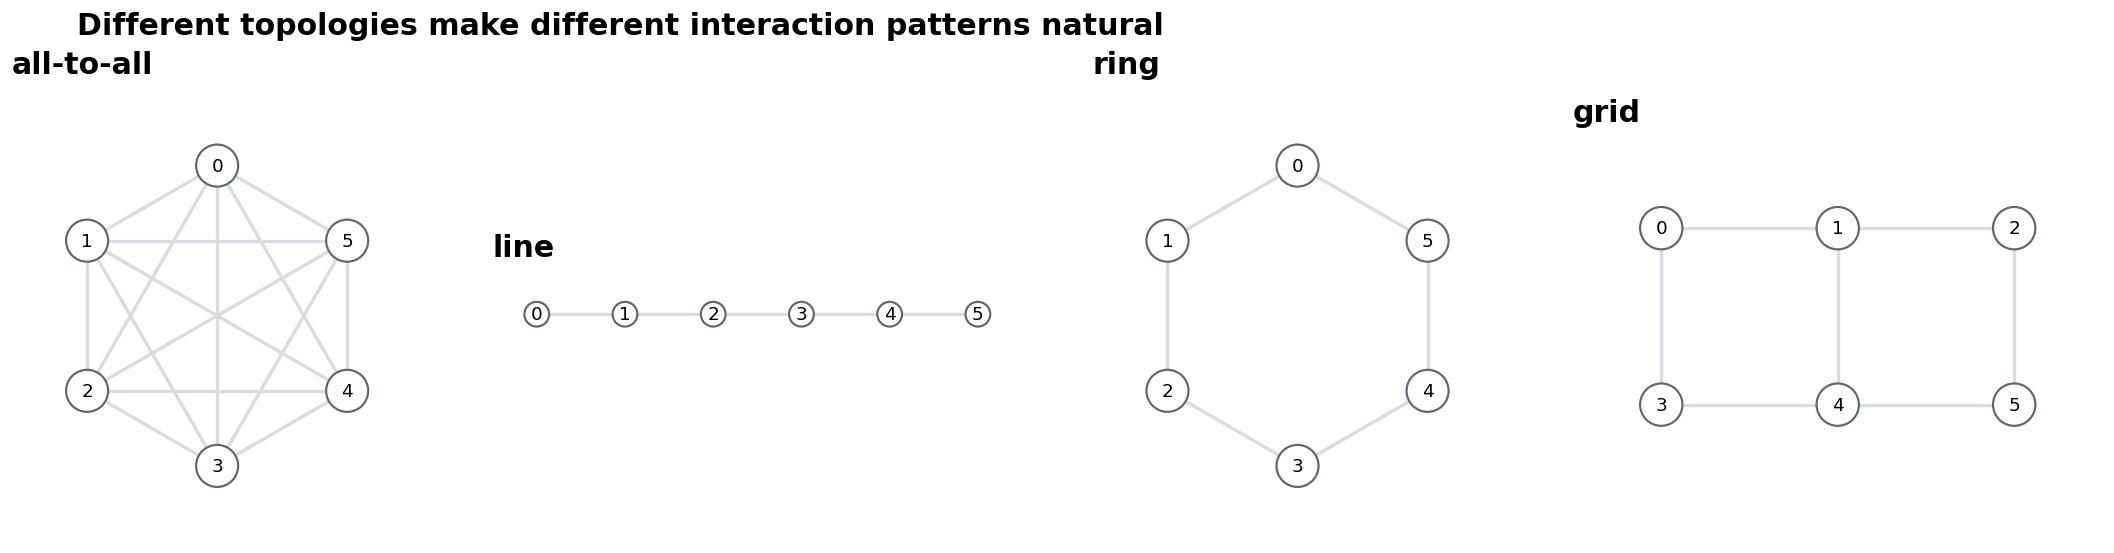

In [27]:
plot_topology_gallery(
    topology_kinds,
    num_qubits=logical_qubit_count,
    title='Different topologies make different interaction patterns natural',
)
plt.show()


All-to-all connectivity minimizes placement pain because every pair is adjacent. A line is the opposite extreme in this notebook: simple to draw, but expensive for long-range interaction. Ring and grid sit in between.


In [28]:
display_wrapped(topology_summary_df)


,topology,device edges,average degree,diameter
0,all-to-all,15,5,1
1,line,5,1.67,5
2,ring,6,2,3
3,grid,7,2.33,3


In [29]:
topology_effect_df = pd.DataFrame(
    {
        'topology': [kind.replace('_', '-') for kind in topology_kinds],
        'avg logical distance for this circuit': [
            routing_detail_df(logical_interactions, kind, logical_qubit_count)['shortest device distance'].mean()
            for kind in topology_kinds
        ],
        'directly supported interactions': [
            int(routing_detail_df(logical_interactions, kind, logical_qubit_count)['directly supported?'].sum())
            for kind in topology_kinds
        ],
    }
)
display_wrapped(topology_effect_df)


,topology,avg logical distance for this circuit,directly supported interactions
0,all-to-all,1,5
1,line,2.6,1
2,ring,1.8,2
3,grid,2.2,1


In [30]:
display_wrapped(Markdown(markdown_box(
    'Topology is analogous to architectural constraints in classical systems. It does not change the abstract problem, but it strongly affects how much movement or routing is needed to execute it.'
)))


> **Takeaway:**
> Topology is analogous to architectural constraints in classical systems. It does not change the abstract problem, but it strongly affects how much movement or routing is needed to execute it.

In [31]:
display_wrapped(Markdown(instructor_prompt(
    'If the logical circuit stays fixed, which topology would you choose first, and what tradeoff would you be accepting?'
)))


> **Instructor Prompt:**
> If the logical circuit stays fixed, which topology would you choose first, and what tradeoff would you be accepting?

## 6. Routing overhead

**Concept question:** If two qubits that need to interact are far apart on the device, how much extra work might the hardware mapping layer impose?


This section uses an explicit toy routing model. It is **not** a real transpiler. We estimate extra routing work by measuring shortest-path distance on the device topology and charging an additional cost whenever a logical interaction is not already local.

The toy routing rule is:

- distance `1` means the interaction is local and needs no extra routing
- distance `d > 1` contributes `d - 1` extra routing steps

This is intentionally simple, but it captures the key intuition that sparse connectivity can force extra movement.


In [32]:
def routing_overhead_summary(logical_edges, kind, num_qubits):
    detail_df = routing_detail_df(logical_edges, kind, num_qubits)
    return {
        'topology': kind.replace('_', '-'),
        'nonlocal interactions': int((~detail_df['directly supported?']).sum()),
        'extra routing steps (toy)': int(detail_df['extra routing steps (toy)'].sum()),
    }


routing_summary_df = pd.DataFrame(
    [routing_overhead_summary(logical_interactions, kind, logical_qubit_count) for kind in topology_kinds]
)


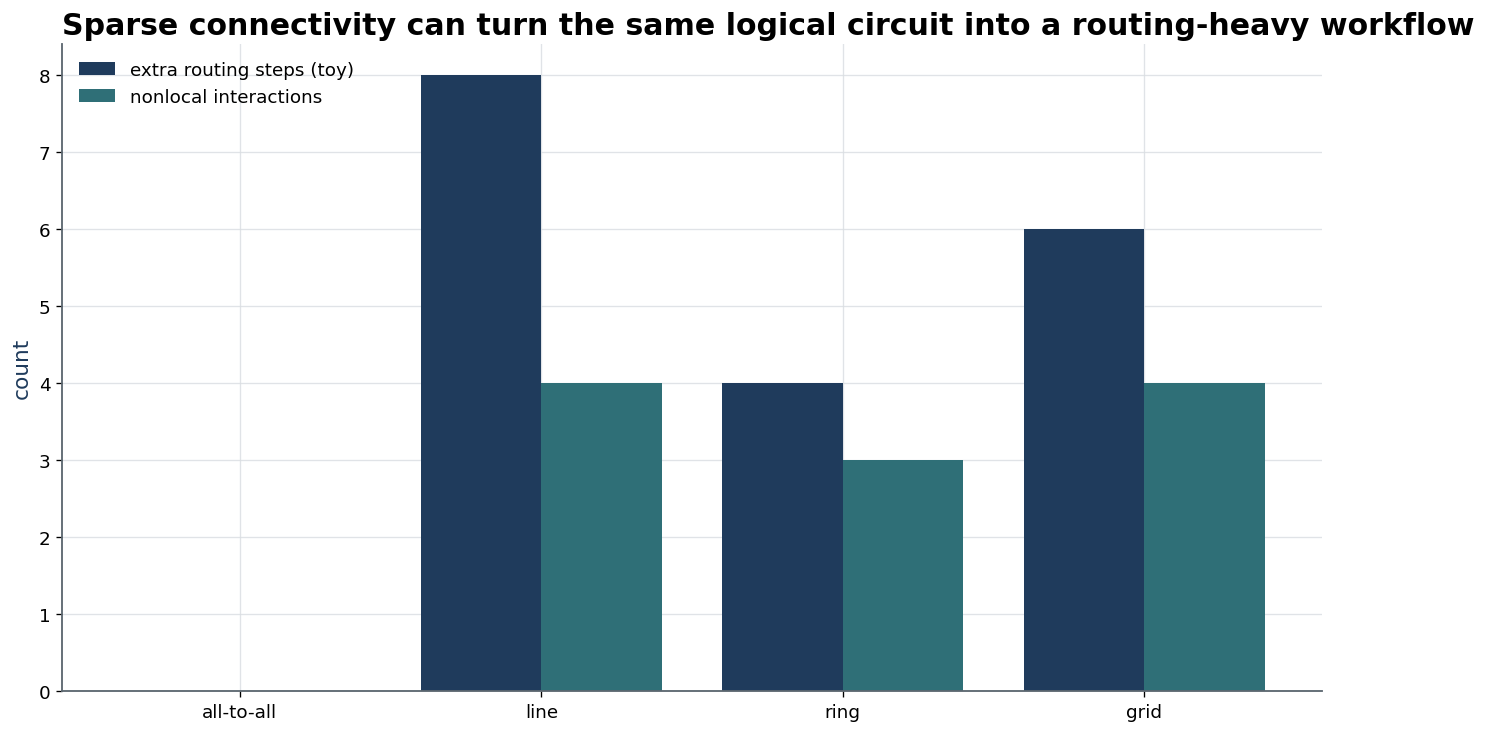

In [33]:
plot_grouped_bars(
    routing_summary_df['topology'],
    {
        'extra routing steps (toy)': routing_summary_df['extra routing steps (toy)'],
        'nonlocal interactions': routing_summary_df['nonlocal interactions'],
    },
    title='Sparse connectivity can turn the same logical circuit into a routing-heavy workflow',
    ylabel='count',
)
plt.show()


The precise numbers are not the main lesson. The visual lesson is that the same logical interaction list can become almost routing-free on one topology and routing-heavy on another.


In [34]:
display_wrapped(line_routing_df)


,logical interaction,shortest device distance,extra routing steps (toy),directly supported?
0,"(0, 5)",5,4,False
1,"(0, 2)",2,1,False
2,"(1, 4)",3,2,False
3,"(2, 3)",1,0,True
4,"(3, 5)",2,1,False


In [35]:
def long_range_pattern(num_qubits):
    """Toy interaction family with intentionally nonlocal pairs."""
    return [(i, num_qubits - 1 - i) for i in range(num_qubits // 2)]


routing_scaling_rows = []
for qubits in [4, 6, 8, 10]:
    pattern = long_range_pattern(qubits)
    for kind in ['all_to_all', 'line', 'ring']:
        detail_df = routing_detail_df(pattern, kind, qubits)
        routing_scaling_rows.append(
            {
                'qubits': qubits,
                'topology': kind.replace('_', '-'),
                'extra routing steps (toy)': int(detail_df['extra routing steps (toy)'].sum()),
            }
        )

routing_scaling_df = pd.DataFrame(routing_scaling_rows)
display_wrapped(routing_scaling_df)


,qubits,topology,extra routing steps (toy)
0,4,all-to-all,0
1,4,line,2
2,4,ring,0
3,6,all-to-all,0
4,6,line,6
5,6,ring,2
6,8,all-to-all,0
7,8,line,12
8,8,ring,4
9,10,all-to-all,0


In [36]:
display_wrapped(Markdown(markdown_box(
    'Routing overhead is analogous to extra movement imposed by hardware limitations. Even a strong logical idea can lose clarity once long-range interactions must be made local.'
)))


> **Takeaway:**
> Routing overhead is analogous to extra movement imposed by hardware limitations. Even a strong logical idea can lose clarity once long-range interactions must be made local.

In [37]:
display_wrapped(Markdown(instructor_prompt(
    'If routing overhead keeps growing while the ideal logical circuit looks small, which number should you trust more for system-level planning?'
)))


> **Instructor Prompt:**
> If routing overhead keeps growing while the ideal logical circuit looks small, which number should you trust more for system-level planning?

## 7. Why theoretical advantage may disappear

**Concept question:** What happens to a promising theoretical gain once input-loading, routing, and repeated shots are included in the same cost picture?


This synthesis section combines several earlier toy components into one full-stack view. The numbers are not hardware predictions. They are cost bookkeeping devices that help students see how an attractive core circuit can be diluted by surrounding costs.


In [38]:
summary_problem_size = 128
summary_logical_edges = long_range_pattern(8)
summary_routing_df = routing_detail_df(summary_logical_edges, 'line', 8)

ideal_core = toy_logical_core_cost(summary_problem_size)
prep_cost = toy_state_preparation_cost(summary_problem_size)
routing_cost = int(summary_routing_df['extra routing steps (toy)'].sum())
measurement_cost = 200

pipeline_components = {
    'core circuit': [ideal_core, ideal_core, ideal_core, ideal_core],
    'state preparation': [0, prep_cost, prep_cost, prep_cost],
    'routing / mapping': [0, 0, routing_cost, routing_cost],
    'shots + post-processing': [0, 0, 0, measurement_cost],
}
pipeline_categories = [
    'ideal circuit only',
    '+ input loading',
    '+ topology-aware routing',
    '+ repeated measurements',
]


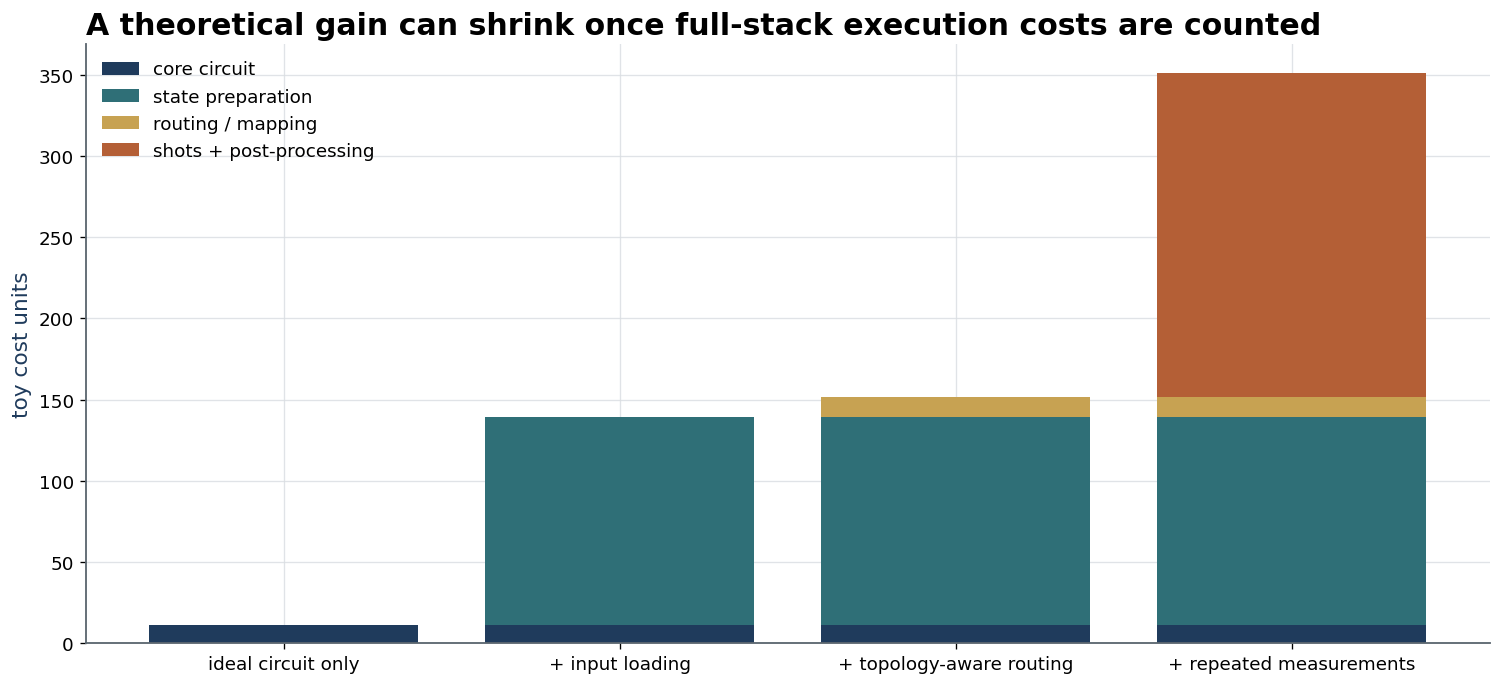

In [39]:
plot_stacked_cost_bars(
    pipeline_categories,
    pipeline_components,
    title='A theoretical gain can shrink once full-stack execution costs are counted',
    ylabel='toy cost units',
)
plt.show()


The plot does not claim that quantum advantage is impossible. It shows a different lesson: a core asymptotic improvement must survive the rest of the execution stack before it becomes meaningful in practice.


In [40]:
pipeline_expression_df = pd.DataFrame(
    {
        'Component': ['core circuit', 'state preparation', 'routing / mapping', 'shots + post-processing'],
        'Toy expression': ['sqrt(n)', 'n', 'depends on topology and interaction distance', 'depends on shots and output estimation'],
        'Lecture role': [
            'abstract algorithmic benefit',
            'input-loading analogue',
            'architectural overhead',
            'statistical and classical output cost',
        ],
    }
)
display_wrapped(pipeline_expression_df)


,Component,Toy expression,Lecture role
0,core circuit,sqrt(n),abstract algorithmic benefit
1,state preparation,n,input-loading analogue
2,routing / mapping,depends on topology and interaction distance,architectural overhead
3,shots + post-processing,depends on shots and output estimation,statistical and classical output cost


In [41]:
erosion_rows = []
for size in [32, 64, 128, 256]:
    core = toy_logical_core_cost(size)
    prep = toy_state_preparation_cost(size)
    route = int(routing_detail_df(long_range_pattern(8), 'line', 8)['extra routing steps (toy)'].sum())
    shots = 200
    total = core + prep + route + shots
    erosion_rows.append(
        {
            'problem size n': size,
            'ideal core only': core,
            'full toy pipeline': total,
            'full / core ratio': total / core,
        }
    )

erosion_df = pd.DataFrame(erosion_rows)
display_wrapped(erosion_df)


,problem size n,ideal core only,full toy pipeline,full / core ratio
0,32,5.66,250,44.1
1,64,8,284,35.5
2,128,11.3,351,31.1
3,256,16,484,30.2


In [42]:
display_wrapped(Markdown(markdown_box(
    'A theoretical advantage may survive, shrink, or vanish after full-stack costs are included. The right question is not only “is the core circuit asymptotically attractive?” but also “what does the entire workflow cost?”'
)))


> **Takeaway:**
> A theoretical advantage may survive, shrink, or vanish after full-stack costs are included. The right question is not only “is the core circuit asymptotically attractive?” but also “what does the entire workflow cost?”

In [43]:
display_wrapped(Markdown(instructor_prompt(
    'If the core algorithm looks good but the full pipeline ratio stays large, would you call that a strong practical advantage yet? Why or why not?'
)))


> **Instructor Prompt:**
> If the core algorithm looks good but the full pipeline ratio stays large, would you call that a strong practical advantage yet? Why or why not?

## 8. Measurement and output constraints

**Concept question:** If a quantum device returns only samples, how do repeated measurements shape the usefulness and cost of the result?


A common conceptual trap is to imagine that the device reveals the entire final quantum state directly. In practice, each run returns a classical sample. To estimate probabilities or identify dominant outcomes, we need repeated measurements, and those repeated shots are part of the cost.

The toy model below uses an ordinary classical probability distribution over bitstrings. That is enough for teaching the measurement story without pretending to simulate real quantum amplitudes.


In [44]:
def sample_bitstrings(probability_map, shots, rng=None):
    """Sample classical bitstrings from a fixed distribution."""
    if rng is None:
        rng = np.random.default_rng(0)
    outcomes = np.array(list(probability_map.keys()))
    probabilities = np.array(list(probability_map.values()), dtype=float)
    samples = rng.choice(outcomes, size=shots, p=probabilities)
    return pd.Series(samples).value_counts().sort_index()


def estimate_success_probability(probability_map, shots, *, trials=300, rng=None):
    """Estimate the average absolute error when learning one target outcome from repeated shots."""
    if rng is None:
        rng = np.random.default_rng(0)
    target_outcome = max(probability_map, key=probability_map.get)
    true_probability = probability_map[target_outcome]
    errors = []
    for _ in range(trials):
        counts = sample_bitstrings(probability_map, shots, rng=rng)
        estimated = counts.get(target_outcome, 0) / shots
        errors.append(abs(estimated - true_probability))
    return float(np.mean(errors))


output_distribution = {'00': 0.08, '01': 0.12, '10': 0.18, '11': 0.62}
measurement_shots = np.array([4, 8, 16, 32, 64, 128, 256, 512])
true_p = output_distribution['11']
theoretical_std_error = np.sqrt(true_p * (1 - true_p) / measurement_shots)
simulated_abs_error = np.array([
    estimate_success_probability(output_distribution, int(shots), trials=300, rng=rng)
    for shots in measurement_shots
])


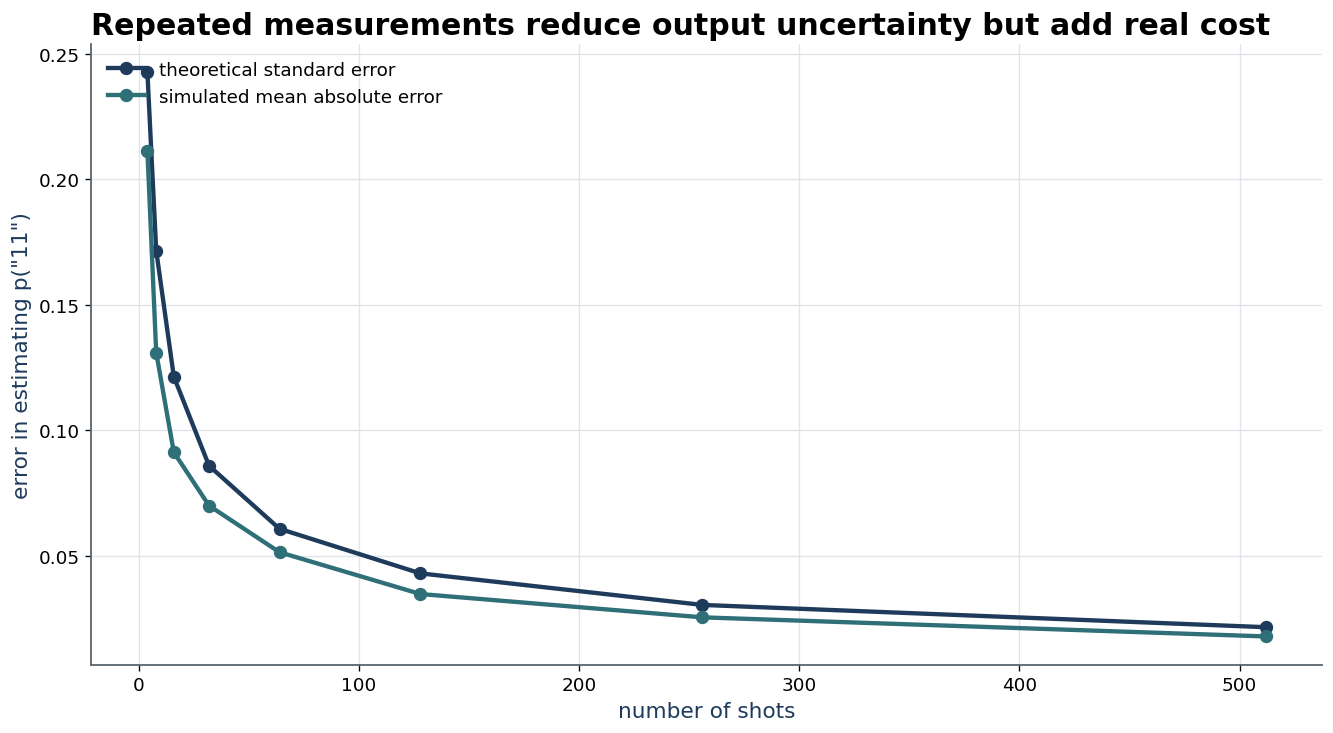

In [45]:
plot_component_tradeoff(
    measurement_shots,
    {
        'theoretical standard error': theoretical_std_error,
        'simulated mean absolute error': simulated_abs_error,
    },
    title='Repeated measurements reduce output uncertainty but add real cost',
    xlabel='number of shots',
    ylabel='error in estimating p("11")',
)
plt.show()


One shot gives one sample. Many shots give a distribution estimate. The visual shows why measurements belong in the cost model: more shots improve output quality, but they are not free.


In [46]:
measurement_formula_df = pd.DataFrame(
    {
        'Question': [
            'What does one run return?',
            'What improves with more shots?',
            'Why does this matter for complexity?',
        ],
        'Answer': [
            'one classical sample, not the full state',
            'stability of estimated probabilities and dominant outputs',
            'the user pays for repeated measurement and post-processing',
        ],
    }
)
display_wrapped(measurement_formula_df)


,Question,Answer
0,What does one run return?,"one classical sample, not the full state"
1,What improves with more shots?,stability of estimated probabilities and dominant outputs
2,Why does this matter for complexity?,the user pays for repeated measurement and post-processing


In [47]:
measurement_examples_df = pd.DataFrame(
    {
        'shots': [8, 256],
        'sample counts': [
            dict(sample_bitstrings(output_distribution, 8, rng=rng)),
            dict(sample_bitstrings(output_distribution, 256, rng=rng)),
        ],
        'estimated p("11")': [
            sample_bitstrings(output_distribution, 8, rng=rng).get('11', 0) / 8,
            sample_bitstrings(output_distribution, 256, rng=rng).get('11', 0) / 256,
        ],
    }
)
display_wrapped(measurement_examples_df)


,shots,sample counts,"estimated p(""11"")"
0,8,"{'10': 4, '11': 4}",0.75
1,256,"{'00': 27, '01': 24, '10': 46, '11': 159}",0.602


In [48]:
display_wrapped(Markdown(markdown_box(
    'Measurement and output access are part of the real cost model. A useful answer often requires many repeated shots plus classical aggregation of the results.'
)))


> **Takeaway:**
> Measurement and output access are part of the real cost model. A useful answer often requires many repeated shots plus classical aggregation of the results.

In [49]:
display_wrapped(Markdown(instructor_prompt(
    'If one run gives only one sample, when would you trust a result without repeated measurements, and when would that be risky?'
)))


> **Instructor Prompt:**
> If one run gives only one sample, when would you trust a result without repeated measurements, and when would that be risky?

## 9. Recap / takeaways


In [50]:
display_wrapped(Markdown(markdown_box(
    'A quantum algorithm is only one layer of a larger workflow. State preparation behaves like input-loading, topology behaves like an architectural constraint, routing behaves like extra movement forced by hardware limits, and repeated measurement behaves like a real statistical output cost. This notebook uses toy abstractions to teach those ideas, not to simulate a full compiler or a real device.',
    title='Recap'
)))


> **Recap:**
> A quantum algorithm is only one layer of a larger workflow. State preparation behaves like input-loading, topology behaves like an architectural constraint, routing behaves like extra movement forced by hardware limits, and repeated measurement behaves like a real statistical output cost. This notebook uses toy abstractions to teach those ideas, not to simulate a full compiler or a real device.

## 10. Questions for students

- Why is it misleading to discuss only the logical circuit and ignore the rest of the execution pipeline?
- In what sense is state preparation analogous to preprocessing or data movement in classical systems?
- Why can the same logical interaction list be cheap on one topology and expensive on another?
- What does the routing toy model capture, and what does it intentionally leave out compared with a real transpiler?
- Why are repeated measurements part of the real cost rather than a minor implementation detail?
- Which implementation layer in this notebook feels most likely to erase an idealized theoretical gain?
